Permutation testing for the big bins I have, take random samples and see if the effects replicate

In [1]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm

import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template # for background image

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
# keep only classification_label=1 and snbb
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

min_age = 30
max_age = 35

# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")

subject_group_size = 100

# choose subject_group_size subject_ids from volumes 



shape of 30 - 35 years old metadata after removing duplicates: (585, 25)


/tmp/ipykernel_32624/2196900548.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')


In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm
import nibabel as nib
from nilearn import plotting
from nilearn.datasets import load_mni152_template
from nilearn.image import new_img_like

# --- 1. Permutation Setup ---
N_PERMUTATIONS = 1000
SAMPLE_SIZE = 100
all_subject_ids = volumes['subject_id'].unique()
# roi_list = volumes['region_label'].unique()
roi_list = [421, 422, 448, 449]

# Dictionary to store Coefficients (beta) for birth_year across runs
coef_accumulator = {roi: [] for roi in roi_list}

print(f"Running {N_PERMUTATIONS} stability permutations for Coefficients...")

for i in tqdm(range(N_PERMUTATIONS)):
    selected_subjects = np.random.choice(all_subject_ids, size=SAMPLE_SIZE, replace=False)
    df_sample = volumes[volumes['subject_id'].isin(selected_subjects)]
    
    for roi, df_roi in df_sample.groupby('region_label'):
        if roi not in roi_list:
            continue
        try:
            model = smf.ols(
                'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
                data=df_roi
            ).fit()
            # CHANGED: Collect coefficient (params) instead of tvalues
            coef_accumulator[roi].append(model.params['birth_year'])
        except:
            continue

# --- 2. Calculate Mean Coefficients ---
mean_coef_map = {roi: np.nanmean(coef_vals) for roi, coef_vals in coef_accumulator.items() if coef_vals}



Running 1000 stability permutations for Coefficients...


100%|██████████| 1000/1000 [00:46<00:00, 21.70it/s]


Mapping mean coefficients to atlas voxels...


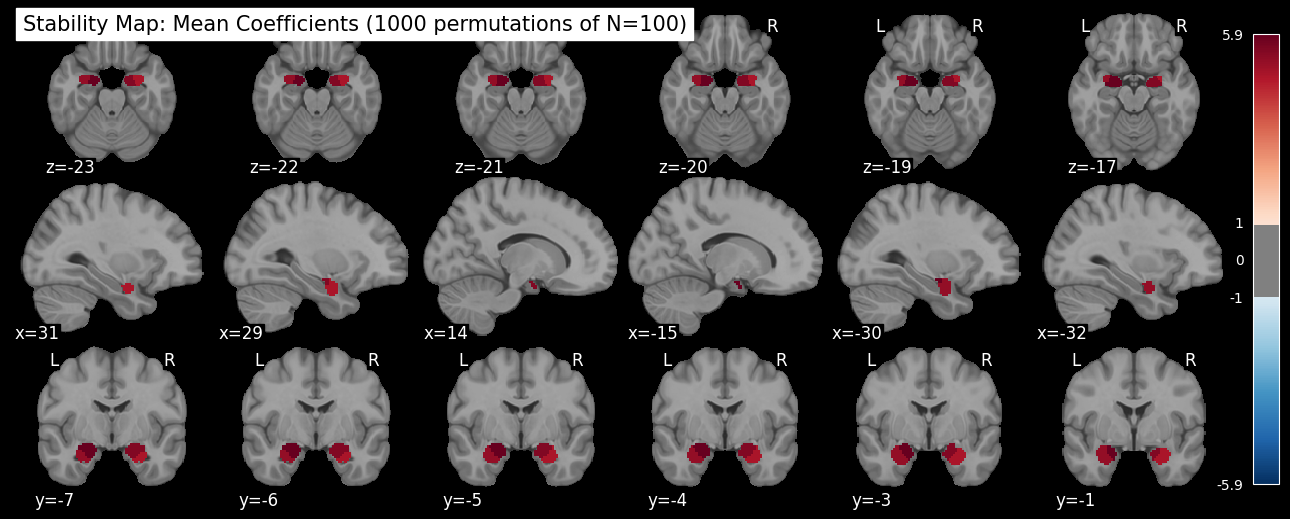

In [6]:
# --- 3. Map Results to Atlas Space ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

stat_map_data = np.zeros_like(atlas_labels, dtype=float)

print("Mapping mean coefficients to atlas voxels...")
for label, mean_coef in mean_coef_map.items():
    stat_map_data[atlas_labels == label] = mean_coef

coef_map_img = new_img_like(atlas_img, stat_map_data)

# --- 4. Plotting ---
bg_img = load_mni152_template()
custom_cut_coords = (6, 6, 6)

plotting.plot_stat_map(
    stat_map_img=coef_map_img,
    bg_img=bg_img,
    title=f"Stability Map: Mean Coefficients ({N_PERMUTATIONS} permutations of N=100)",
    cmap='RdBu_r', # Red = Volume increase per year, Blue = Volume decrease
    symmetric_cbar=True,
    threshold=1, # Adjusted: Coefs can be small; set this based on your expected effect size
    display_mode='mosaic',
    cut_coords=custom_cut_coords,
    colorbar=True
)

plotting.show()

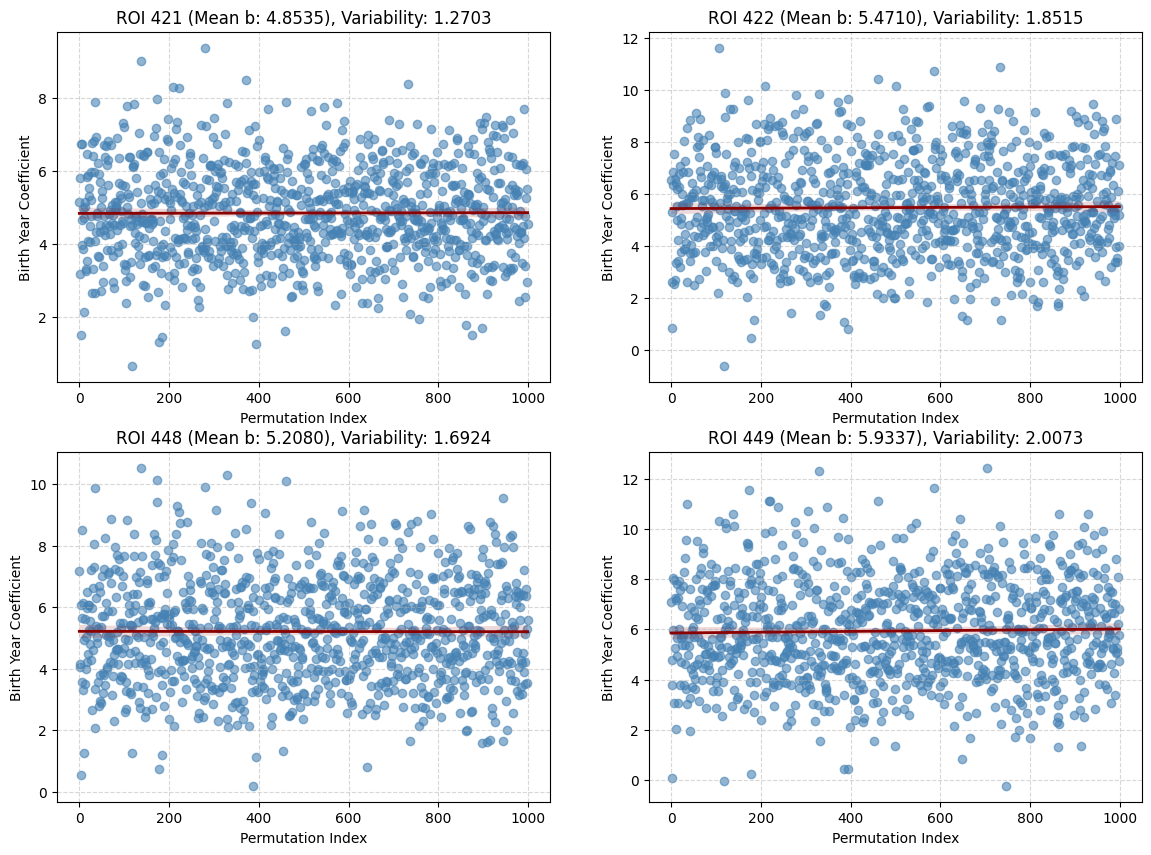

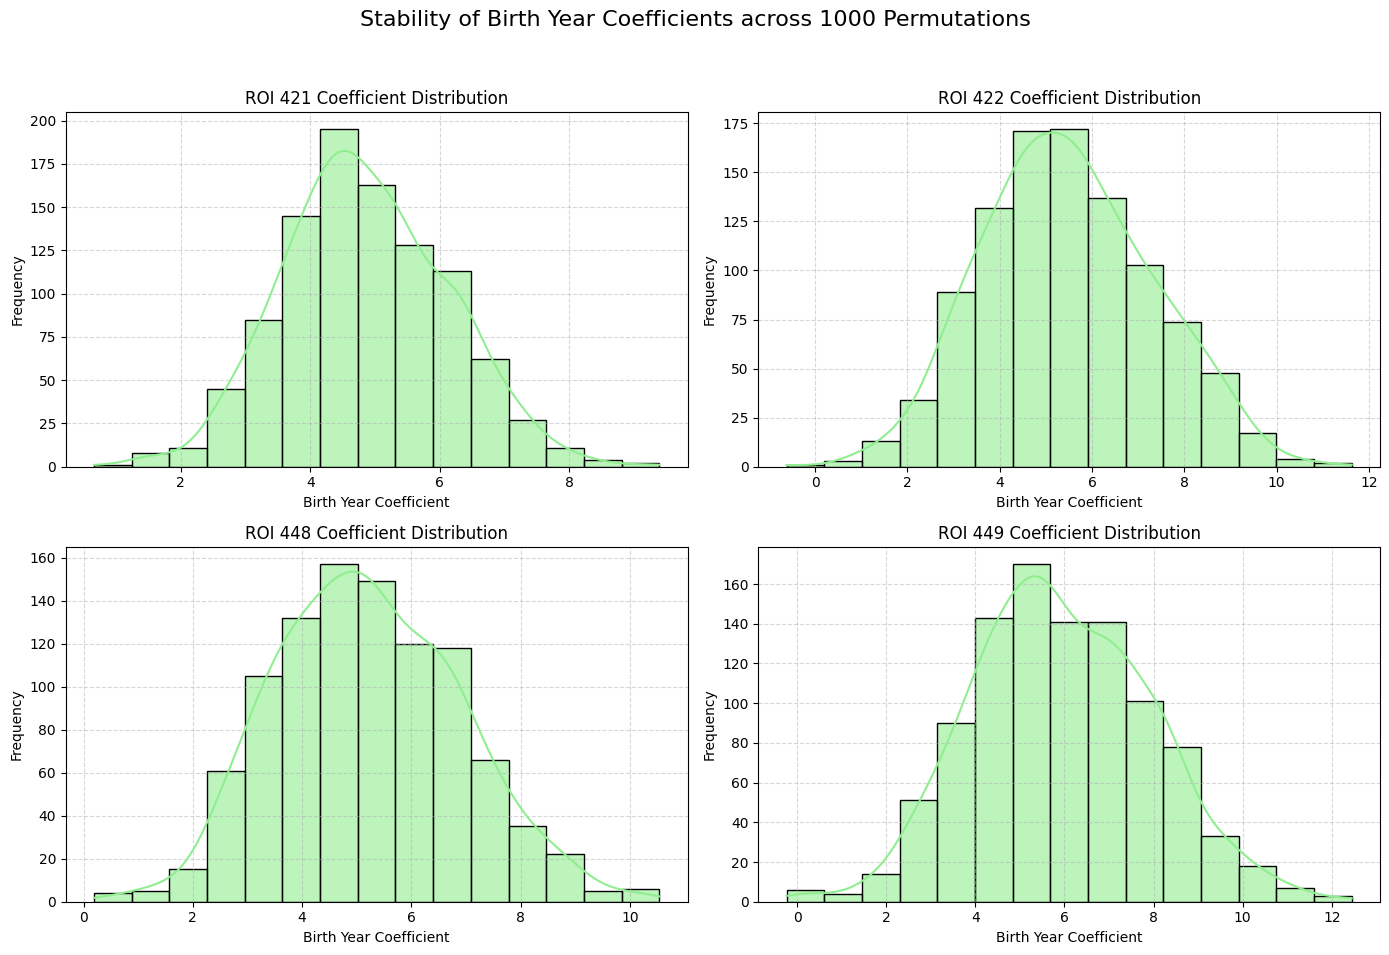

In [9]:
import seaborn as sns

# --- 2. Visualization: Specific ROI Scatter Plots ---
# Create 2 plots with 2x2 grid for the 4 target ROIs
fig1, axes = plt.subplots(2, 2, figsize=(14, 10)) # scatter plots
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10)) # histograms
axes = axes.flatten()
axes2 = axes2.flatten()

for i, roi in enumerate(roi_list):
    if roi in coef_accumulator and len(coef_accumulator[roi]) > 0:
        # Create a temporary dataframe for this ROI's results
        df_roi_viz = pd.DataFrame({
            'Permutation': range(len(coef_accumulator[roi])),
            'Beta': coef_accumulator[roi]
        })
        
        # Plot scatter + regression line
        sns.regplot(
            data=df_roi_viz,
            x='Permutation',
            y='Beta',
            ax=axes[i],
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
            line_kws={'color': 'darkred', 'lw': 2}
        )
        
        # Plot histogram
        sns.histplot(
            data=df_roi_viz,
            x='Beta',
            bins=15,
            kde=True,
            ax=axes2[i],
            color='lightgreen',
            alpha=0.6
        )
        
        # Calculate mean and stats for the title of both plots
        mean_val = np.mean(coef_accumulator[roi])
        axes[i].set_title(f'ROI {roi} (Mean b: {mean_val:.4f}), Variability: {np.std(coef_accumulator[roi]):.4f}')
        axes[i].set_xlabel('Permutation Index')
        axes[i].set_ylabel('Birth Year Coefficient')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes2[i].set_title(f'ROI {roi} Coefficient Distribution')
        axes2[i].set_xlabel('Birth Year Coefficient')
        axes2[i].set_ylabel('Frequency')
        axes2[i].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[i].set_title(f'ROI {roi} (No data available)')
        axes2[i].set_title(f'ROI {roi} (No data available)')


plt.suptitle(f'Stability of Birth Year Coefficients across {N_PERMUTATIONS} Permutations', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()